In [18]:
# Step 1: Import the libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [19]:
# Step 2: Load the MNIST handwritten-digit dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


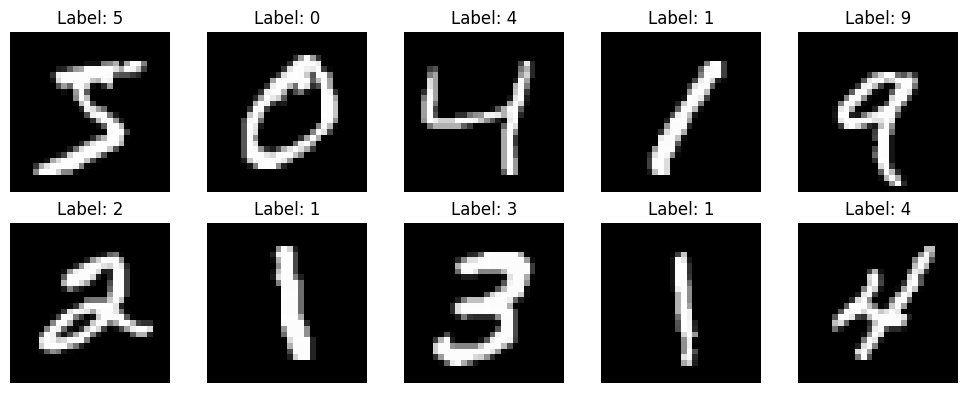

In [20]:
# Step 3: Display sample MNIST images

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Step 4: Normalize and reshape the images

# Keep original 0–255 images for creating sample CSV files later
x_train_raw = x_train.copy()
x_test_raw = x_test.copy()

# Scale pixel values from 0–255 to 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the grayscale channel: (28, 28) becomes (28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [22]:
# Step 5: Build the Convolutional Neural Network (CNN)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Step 6: Compile the CNN

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [24]:
# Step 7: Train the CNN and save the best version

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "mnist_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint]
)

Epoch 1/5
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8574 - loss: 0.4593
Epoch 1: val_accuracy improved from None to 0.98333, saving model to mnist_model.keras

Epoch 1: finished saving model to mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9353 - loss: 0.2072 - val_accuracy: 0.9833 - val_loss: 0.0571
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9786 - loss: 0.0689
Epoch 2: val_accuracy improved from 0.98333 to 0.98617, saving model to mnist_model.keras

Epoch 2: finished saving model to mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9803 - loss: 0.0637 - val_accuracy: 0.9862 - val_loss: 0.0459
Epoch 3/5
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9843 - loss: 0.0498
Epoch 3: val_accuracy improved from 0.98617 to 0.98900, saving model to mnist_model.keras

Epoch 3: finished saving model to mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9856 - loss: 0.0469 -

In [25]:
# Step 8: Load the best saved model and evaluate it on the test set

best_model = tf.keras.models.load_model("mnist_model.keras")

test_loss, test_accuracy = best_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9920 - loss: 0.0235

Test loss: 0.0235
Test accuracy: 99.2000%


In [26]:
# Step 9: Build an improved CNN to target 99.5% accuracy

improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,714 (1.79 MB)

 Trainable params: 468,266 (1.79 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
# Step 10: Train the improved CNN

improved_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "mnist_model_improved.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=1,
    min_lr=0.00001,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

improved_history = improved_model.fit(
    x_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    callbacks=[improved_checkpoint, reduce_lr, early_stop]
)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.8737 - loss: 0.4086
Epoch 1: val_accuracy improved from None to 0.98592, saving model to mnist_model_improved.keras

Epoch 1: finished saving model to mnist_model_improved.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 228s 300ms/step - accuracy: 0.9421 - loss: 0.1889 - val_accuracy: 0.9859 - val_loss: 0.0458 - learning_rate: 0.0010
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9777 - loss: 0.0729
Epoch 2: val_accuracy improved from 0.98592 to 0.99008, saving model to mnist_model_improved.keras

Epoch 2: finished saving model to mnist_model_improved.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 253s 288ms/step - accuracy: 0.9797 - loss: 0.0661 - val_accuracy: 0.9901 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9831 - loss: 0.0562
Epoch 3: val_accuracy did not improve from 0.99008
750/750 ━━━━━━━━━━━━━━━━━━━━ 224s 298ms/step - accuracy: 0.9841 - loss: 0.0515 

In [28]:
# Step 11: Evaluate the improved model on unseen test data

final_model = tf.keras.models.load_model("mnist_model_improved.keras")

final_test_loss, final_test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"\nImproved model test loss: {final_test_loss:.4f}")
print(f"Improved model test accuracy: {final_test_accuracy:.4%}")
print(f"Correct predictions: approximately {final_test_accuracy * len(y_test):.0f} out of {len(y_test)}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9940 - loss: 0.0181

Improved model test loss: 0.0181
Improved model test accuracy: 99.4000%
Correct predictions: approximately 9940 out of 10000


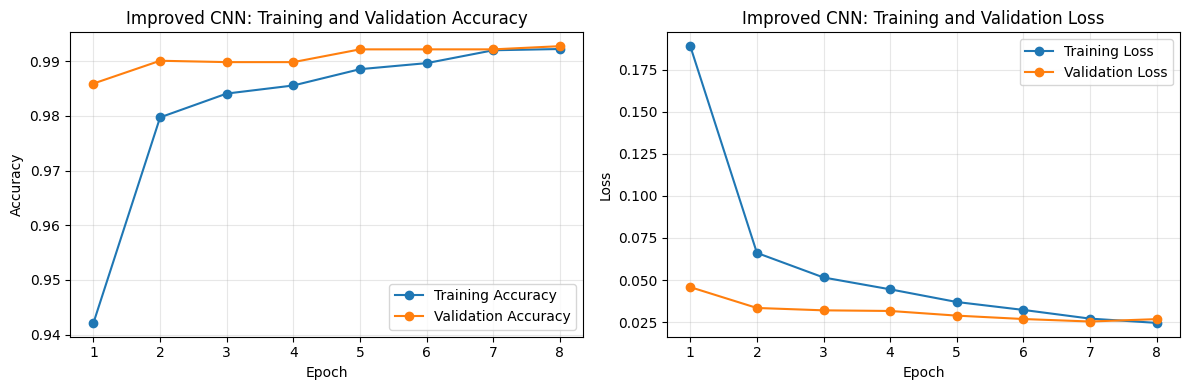

In [29]:
# Step 12: Plot training and validation accuracy and loss

epochs = range(1, len(improved_history.history["accuracy"]) + 1)

plt.figure(figsize=(12, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, improved_history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs, improved_history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Improved CNN: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, improved_history.history["loss"], marker="o", label="Training Loss")
plt.plot(epochs, improved_history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Improved CNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

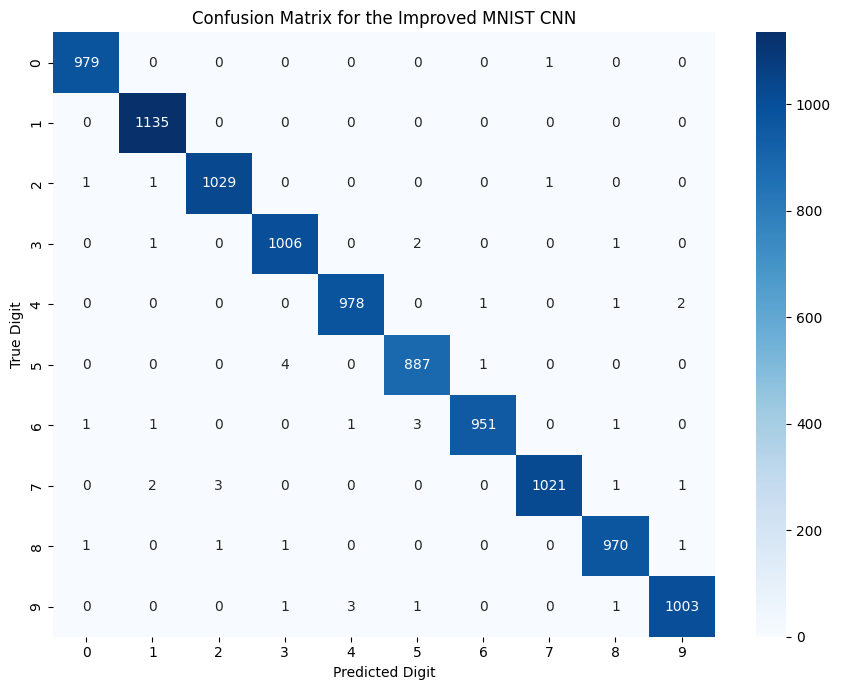


Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9990    0.9980       980
           1     0.9956    1.0000    0.9978      1135
           2     0.9961    0.9971    0.9966      1032
           3     0.9941    0.9960    0.9951      1010
           4     0.9959    0.9959    0.9959       982
           5     0.9933    0.9944    0.9938       892
           6     0.9979    0.9927    0.9953       958
           7     0.9980    0.9932    0.9956      1028
           8     0.9949    0.9959    0.9954       974
           9     0.9960    0.9941    0.9950      1009

    accuracy                         0.9959     10000
   macro avg     0.9959    0.9958    0.9959     10000
weighted avg     0.9959    0.9959    0.9959     10000



In [36]:
# Step 13: Predict the test images and create a confusion matrix

probabilities = final_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix for the Improved MNIST CNN")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, digits=4))

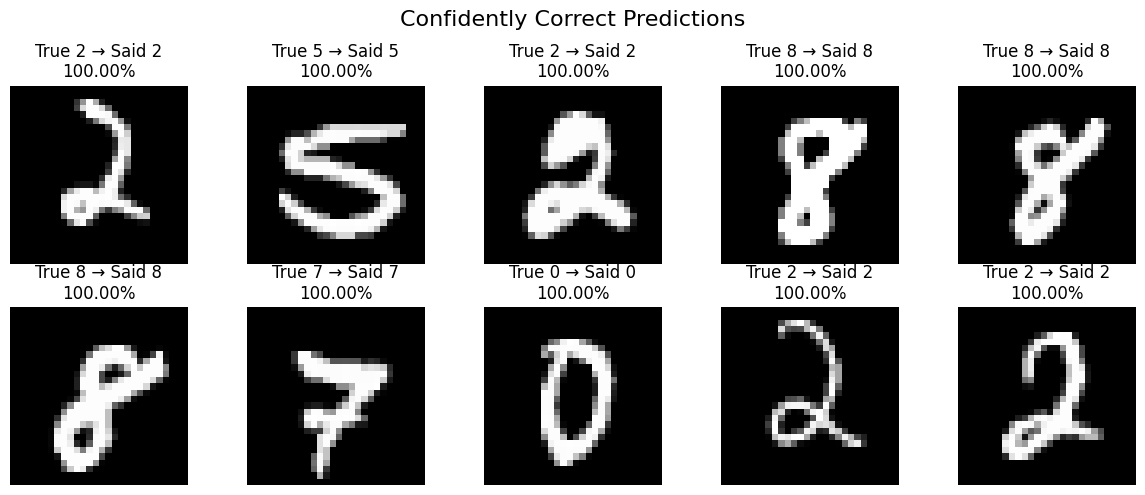

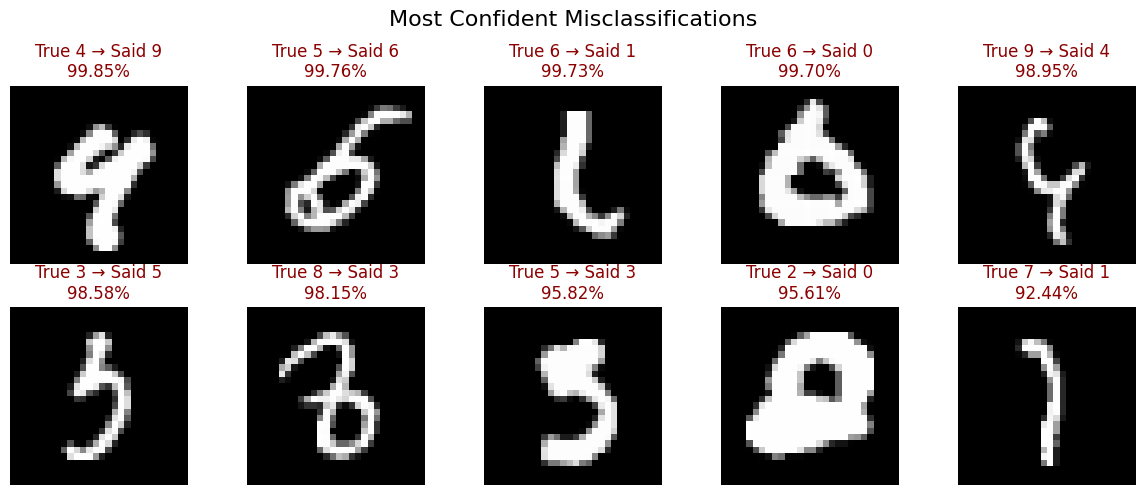

Total misclassified images: 41


In [37]:
# Step 14: Display confidently correct and confidently wrong predictions

prediction_confidence = np.max(probabilities, axis=1)

correct_indices = np.where(predicted_labels == y_test)[0]
wrong_indices = np.where(predicted_labels != y_test)[0]

# Sort both groups from highest to lowest confidence
top_correct = correct_indices[
    np.argsort(prediction_confidence[correct_indices])[::-1][:10]
]

top_wrong = wrong_indices[
    np.argsort(prediction_confidence[wrong_indices])[::-1][:10]
]

# Confidently correct examples
plt.figure(figsize=(12, 5))

for i, index in enumerate(top_correct):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index].squeeze(), cmap="gray")
    plt.title(
        f"True {y_test[index]} → Said {predicted_labels[index]}\n"
        f"{prediction_confidence[index]:.2%}"
    )
    plt.axis("off")

plt.suptitle("Confidently Correct Predictions", fontsize=16)
plt.tight_layout()
plt.savefig("correct_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

# Confidently incorrect examples
plt.figure(figsize=(12, 5))

for i, index in enumerate(top_wrong):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index].squeeze(), cmap="gray")
    plt.title(
        f"True {y_test[index]} → Said {predicted_labels[index]}\n"
        f"{prediction_confidence[index]:.2%}",
        color="darkred"
    )
    plt.axis("off")

plt.suptitle("Most Confident Misclassifications", fontsize=16)
plt.tight_layout()
plt.savefig("misclassified_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

print("Total misclassified images:", len(wrong_indices))

In [38]:
# Step 15: Save the final model and generate valid and invalid sample files

import os
import shutil

os.makedirs("samples/bad", exist_ok=True)

# Save the improved model under the final filename expected by the project
final_model.save("mnist_model.keras")

# Create one valid 0–255 CSV for each digit
for digit in range(10):
    index = np.where(y_test == digit)[0][0]
    np.savetxt(
        f"samples/digit_{digit}_255.csv",
        x_test_raw[index],
        delimiter=",",
        fmt="%d"
    )

# Create one valid 0–1 CSV to test automatic scale detection
scaled_index = np.where(y_test == 5)[0][0]
np.savetxt(
    "samples/digit_5_scaled_0_to_1.csv",
    x_test[scaled_index].squeeze(),
    delimiter=",",
    fmt="%.6f"
)

# Invalid file: wrong extension
with open("samples/bad/not_a_csv.txt", "w") as file:
    file.write("This is deliberately not a CSV file.")

# Invalid file: wrong 10x10 shape
np.savetxt(
    "samples/bad/wrong_shape_10x10.csv",
    np.zeros((10, 10)),
    delimiter=",",
    fmt="%d"
)

# Invalid file: header row
np.savetxt(
    "samples/bad/contains_header.csv",
    x_test_raw[0],
    delimiter=",",
    fmt="%d",
    header="This file contains a header row",
    comments=""
)

# Invalid file: contains text
text_array = x_test_raw[0].astype(object)
text_array[0, 0] = "text"
np.savetxt(
    "samples/bad/contains_text.csv",
    text_array,
    delimiter=",",
    fmt="%s"
)

print("Final model saved as: mnist_model.keras")
print("\nValid sample files:")
print(sorted(os.listdir("samples")))

print("\nInvalid sample files:")
print(sorted(os.listdir("samples/bad")))

Final model saved as: mnist_model.keras

Valid sample files:
['bad', 'digit_0_255.csv', 'digit_1_255.csv', 'digit_2_255.csv', 'digit_3_255.csv', 'digit_4_255.csv', 'digit_5_255.csv', 'digit_5_scaled_0_to_1.csv', 'digit_6_255.csv', 'digit_7_255.csv', 'digit_8_255.csv', 'digit_9_255.csv']

Invalid sample files:
['contains_header.csv', 'contains_text.csv', 'not_a_csv.txt', 'wrong_shape_10x10.csv']


In [39]:
# Step 16: Package the model, analysis images, and samples for GitHub

from google.colab import files

os.makedirs("harelle_model_handoff/classifier/ml", exist_ok=True)
os.makedirs("harelle_model_handoff/static/analysis", exist_ok=True)

# Copy the final model
shutil.copy(
    "mnist_model.keras",
    "harelle_model_handoff/classifier/ml/mnist_model.keras"
)

# Copy the analysis images
for image_file in [
    "training_curves.png",
    "confusion_matrix.png",
    "correct_predictions.png",
    "misclassified_predictions.png"
]:
    shutil.copy(
        image_file,
        f"harelle_model_handoff/static/analysis/{image_file}"
    )

# Copy all valid and invalid sample files
shutil.copytree(
    "samples",
    "harelle_model_handoff/samples",
    dirs_exist_ok=True
)

# Create one downloadable ZIP file
shutil.make_archive(
    "harelle_model_handoff",
    "zip",
    "harelle_model_handoff"
)

print("Package created successfully.")
files.download("harelle_model_handoff.zip")

Package created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# Step 18: Retrain the selected CNN architecture on the full training set

tf.keras.utils.set_random_seed(42)

full_model = tf.keras.models.clone_model(improved_model)

full_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

full_history = full_model.fit(
    x_train,
    y_train,
    epochs=8,
    batch_size=64,
    verbose=1
)

# Make this the final model used by all later analysis
final_model = full_model

final_test_loss, final_test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

final_model.save("mnist_model.keras")

print(f"\nFinal full-data test loss: {final_test_loss:.4f}")
print(f"Final full-data test accuracy: {final_test_accuracy:.4%}")
print(f"Correct predictions: approximately {final_test_accuracy * len(y_test):.0f} out of {len(y_test)}")

Epoch 1/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 264s 277ms/step - accuracy: 0.9517 - loss: 0.1607
Epoch 2/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 259s 276ms/step - accuracy: 0.9818 - loss: 0.0606
Epoch 3/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 275ms/step - accuracy: 0.9860 - loss: 0.0462
Epoch 4/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 259s 276ms/step - accuracy: 0.9884 - loss: 0.0384
Epoch 5/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 276ms/step - accuracy: 0.9900 - loss: 0.0321
Epoch 6/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 274ms/step - accuracy: 0.9903 - loss: 0.0296
Epoch 7/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 273ms/step - accuracy: 0.9912 - loss: 0.0279
Epoch 8/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 262s 274ms/step - accuracy: 0.9924 - loss: 0.0241
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9932 - loss: 0.0192

Final full-data test loss: 0.0192
Final full-data test accuracy: 99.3200%
Correct predictions: approximately 9932 out of 10000


In [35]:
# Step 19: Fine-tune the full-data model with a smaller learning rate

full_model.optimizer.learning_rate.assign(0.0001)

fine_tune_history = full_model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=64,
    verbose=1
)

final_model = full_model

final_test_loss, final_test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

final_model.save("mnist_model.keras")

print(f"\nFine-tuned final test loss: {final_test_loss:.4f}")
print(f"Fine-tuned final test accuracy: {final_test_accuracy:.4%}")
print(f"Correct predictions: approximately {final_test_accuracy * len(y_test):.0f} out of {len(y_test)}")

Epoch 1/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 257s 274ms/step - accuracy: 0.9949 - loss: 0.0162
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 273ms/step - accuracy: 0.9963 - loss: 0.0126
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 263s 274ms/step - accuracy: 0.9971 - loss: 0.0103
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 262s 274ms/step - accuracy: 0.9967 - loss: 0.0101
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9959 - loss: 0.0124

Fine-tuned final test loss: 0.0124
Fine-tuned final test accuracy: 99.5900%
Correct predictions: approximately 9959 out of 10000
